# 🤖 Notebook 3: Delay Prediction Model
### SupplyChain-AI-Agent | AIML Lab Assignment

**Input:** `Datasets/processed_data.csv` + `Datasets/feature_cols.json`  
**Output:** `models/delay_model.pkl` + `Datasets/predictions.csv`

**What we do here:**
- Train a Random Forest and compare with Logistic Regression (baseline)
- Evaluate with Accuracy, Classification Report, Confusion Matrix, ROC-AUC
- Save the best model and predictions for every order

---

## 0. Imports & Setup

In [14]:
import pandas as pd               # for loading data and building the predictions DataFrame
import numpy as np                # for array operations (e.g. computing probabilities)
import matplotlib.pyplot as plt   # for drawing all evaluation charts
import seaborn as sns             # for the heatmap on the confusion matrix
import json                       # for reading feature_cols.json saved by Notebook 2
import os                         # for creating the models/ directory
import pickle                     # for saving the trained model to a .pkl file
import warnings

# Individual ML classes from scikit-learn:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
# train_test_split: splits data into training and testing sets
# cross_val_score: evaluates model using cross-validation
# StratifiedKFold: k-fold that preserves class ratio in each fold

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# RandomForestClassifier: builds many decision trees and averages their predictions
# GradientBoostingClassifier: builds trees sequentially, each correcting the last

from sklearn.linear_model import LogisticRegression
# LogisticRegression: simple linear model — used here as the baseline to beat

from sklearn.metrics import (
    accuracy_score,           # fraction of predictions that are correct
    classification_report,    # precision, recall, F1 for each class
    confusion_matrix,         # 2×2 table of TP, TN, FP, FN
    roc_auc_score,            # Area Under the ROC Curve — discrimination ability
    roc_curve                 # computes the ROC curve data points for plotting
)
from sklearn.preprocessing import StandardScaler
# StandardScaler: transforms features to zero mean / unit variance
# Required for Logistic Regression but not for tree-based models

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

# Create the models/ directory if it doesn't already exist
# exist_ok=True prevents an error if the folder already exists
os.makedirs('../models', exist_ok=True)
print('✅ Libraries loaded.')

✅ Libraries loaded.


## 1. Load Data

In [15]:
# Load the processed dataset created by Notebook 2
df = pd.read_csv('../Datasets/processed_data.csv')

# Load the exact list of feature columns that Notebook 2 saved
# Using the same JSON ensures Notebook 3 uses exactly the same features
with open('../Datasets/feature_cols.json') as f:
    FEATURE_COLS = json.load(f)   # json.load reads the JSON file into a Python list

# Name of the column we want to predict
TARGET_COL = 'Late_delivery_risk'

# Safety check: only keep feature columns that actually exist in the DataFrame
# (guards against any columns that might have been skipped in Notebook 2)
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

print(f'Dataset: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Features used: {len(FEATURE_COLS)}')

# Print class balance — important to know if classes are imbalanced before training
# Here: 1 (Late) has ~98k orders, 0 (On Time) has ~81k — slight imbalance
print(f'Target balance:\n{df[TARGET_COL].value_counts()}')

Dataset: 180,519 rows × 28 cols
Features used: 26
Target balance:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64


---
## 2. Prepare Train / Test Split

In [16]:
# X = feature matrix (all input columns the model uses to make predictions)
# y = target vector (0 = on time, 1 = late — what the model must predict)
X = df[FEATURE_COLS]
y = df[TARGET_COL]

# Split data: 80% for training, 20% for testing
# test_size=0.2 → 20% of rows go to test set, remaining 80% for training
# random_state=42 → fixes the random seed so results are reproducible
# stratify=y → ensures both train and test sets have the same % of late orders
#              (without stratify, random splits could give very different class ratios)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set : {X_train.shape[0]:,} samples')
print(f'Test set  : {X_test.shape[0]:,} samples')
print(f'\nClass distribution in train:')
print(y_train.value_counts(normalize=True).round(3))  # normalize=True shows fractions not counts

Train set : 144,415 samples
Test set  : 36,104 samples

Class distribution in train:
Late_delivery_risk
1    0.548
0    0.452
Name: proportion, dtype: float64


## 3. Train Models
### 3.1 Baseline — Logistic Regression

In [17]:
# Logistic Regression requires features to be on the same scale
# StandardScaler: subtracts mean and divides by std → all features become centred around 0
scaler = StandardScaler()

# fit_transform on TRAINING data: learn the mean/std from train, then scale it
X_train_scaled = scaler.fit_transform(X_train)

# transform on TEST data: apply the SAME scaling (don't re-fit on test — that would be data leakage)
X_test_scaled  = scaler.transform(X_test)

# Create and train Logistic Regression
# max_iter=500 gives the solver enough iterations to converge on this many features
# random_state=42 for reproducibility
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_scaled, y_train)   # learn the decision boundary from training data

# Predict class labels for the test set
lr_preds = lr.predict(X_test_scaled)

# Accuracy: fraction of test predictions that match the actual labels
lr_acc = accuracy_score(y_test, lr_preds)

# ROC-AUC: measures how well the model separates late from on-time orders
# predict_proba returns [prob_class0, prob_class1] — we take [:, 1] for late probability
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])

print(f'Logistic Regression → Accuracy: {lr_acc:.4f} | AUC: {lr_auc:.4f}')

Logistic Regression → Accuracy: 0.6967 | AUC: 0.7304


### 3.2 Random Forest Classifier

In [18]:
# Random Forest builds many decision trees and combines them
# Each tree sees a random subset of rows (bootstrap sample) and random subset of features
# The final prediction is the majority vote across all trees

rf = RandomForestClassifier(
    n_estimators=300,        # number of trees — more trees = more stable, but slower
    max_depth=15,            # maximum depth of each tree — limits overfitting
    min_samples_leaf=5,      # each leaf must have at least 5 samples — prevents memorising noise
    min_samples_split=10,    # a node needs at least 10 samples before it can be split further
    max_features='sqrt',     # each split considers sqrt(total_features) features — adds randomness
    class_weight='balanced', # upweights the minority class (on-time orders) to handle class imbalance
    random_state=42,         # fixed seed for reproducibility
    n_jobs=-1                # use all available CPU cores to speed up training
)

# Train the Random Forest on the training data
rf.fit(X_train, y_train)

# Predict on the test set
rf_preds = rf.predict(X_test)

# predict_proba returns probability for each class; [:, 1] gives probability of being LATE
rf_probs = rf.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_preds)       # test accuracy
rf_auc = roc_auc_score(y_test, rf_probs)         # test AUC

# Check training accuracy to detect overfitting (train acc >> test acc = overfitting)
train_acc = accuracy_score(y_train, rf.predict(X_train))
print(f'Train Accuracy : {train_acc:.4f}')
print(f'Test  Accuracy : {rf_acc:.4f}   ← this is what matters')
print(f'AUC            : {rf_auc:.4f}')
gap = train_acc - rf_acc
print(f'Train-Test Gap : {gap:.4f}  {"✅ Good (< 0.05)" if gap < 0.05 else "⚠️ Some overfitting"}')

Train Accuracy : 0.7229
Test  Accuracy : 0.7132   ← this is what matters
AUC            : 0.7714
Train-Test Gap : 0.0096  ✅ Good (< 0.05)


### 3.3 Gradient Boosting Classifier

In [19]:
# Gradient Boosting trains trees sequentially — each new tree focuses on
# correcting the errors made by the previous trees
# This iterative error-correction often achieves higher accuracy than Random Forest

gb = GradientBoostingClassifier(
    n_estimators=300,      # total number of boosting stages (trees)
    learning_rate=0.05,    # how much each tree contributes — small = slower but more stable
    max_depth=5,           # shallower trees reduce overfitting in boosting
    min_samples_leaf=10,   # each leaf needs at least 10 samples
    subsample=0.85,        # use 85% of rows per tree — adds randomness, reduces variance
    max_features='sqrt',   # use sqrt(n_features) per split — adds randomness
    random_state=42
)
gb.fit(X_train, y_train)   # train on the training data

gb_preds = gb.predict(X_test)                   # predicted class labels
gb_probs = gb.predict_proba(X_test)[:, 1]       # predicted probabilities for class 1 (late)
gb_acc   = accuracy_score(y_test, gb_preds)     # test accuracy
gb_auc   = roc_auc_score(y_test, gb_probs)      # test AUC
gb_train_acc = accuracy_score(y_train, gb.predict(X_train))  # train accuracy for gap check

print(f'Gradient Boosting → Train Acc: {gb_train_acc:.4f} | Test Acc: {gb_acc:.4f} | AUC: {gb_auc:.4f}')
print(f'Train-Test Gap    : {gb_train_acc - gb_acc:.4f}')

# ── Select the best model based on test accuracy ──────────────────────────
# Whichever model scored higher on the held-out test set becomes the 'best model'
if gb_acc >= rf_acc:
    best_model  = gb            # Gradient Boosting wins
    best_preds  = gb_preds
    best_probs  = gb_probs
    best_acc    = gb_acc
    best_name   = 'Gradient Boosting'
    best_train_acc = gb_train_acc
else:
    best_model  = rf            # Random Forest wins
    best_preds  = rf_preds
    best_probs  = rf_probs
    best_acc    = rf_acc
    best_name   = 'Random Forest'
    best_train_acc = train_acc

print(f'\n🏆 Best model selected: {best_name} (Test Accuracy: {best_acc:.4f})')

Gradient Boosting → Train Acc: 0.7159 | Test Acc: 0.7125 | AUC: 0.7721
Train-Test Gap    : 0.0034

🏆 Best model selected: Random Forest (Test Accuracy: 0.7132)


## 4. Evaluation
### 4.1 Cross-Validation

In [20]:
# StratifiedKFold splits data into 5 folds while preserving the class ratio in each fold
# shuffle=True randomises the data before splitting (random_state keeps it reproducible)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cross_val_score trains and evaluates the model 5 times on different train/test splits
# scoring='accuracy' means it measures accuracy on each fold's test portion
# n_jobs=-1 runs all folds in parallel using all CPU cores
cv_scores = cross_val_score(best_model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)

print(f'5-Fold CV ({best_name}):')
print(f'  Scores : {np.round(cv_scores, 4)}')   # accuracy on each of the 5 folds
print(f'  Mean   : {cv_scores.mean():.4f}')       # average across all 5 folds
print(f'  Std Dev: {cv_scores.std():.4f}')        # how much performance varies across folds
# 95% confidence interval: mean ± 2 standard deviations
print(f'  95% CI : [{cv_scores.mean() - 2*cv_scores.std():.4f}, {cv_scores.mean() + 2*cv_scores.std():.4f}]')

5-Fold CV (Random Forest):
  Scores : [0.7113 0.7122 0.7092 0.7128 0.7142]
  Mean   : 0.7119
  Std Dev: 0.0016
  95% CI : [0.7086, 0.7152]


### 4.2 Classification Report

In [21]:
# The classification report shows performance metrics for each class:
#   Precision: of all orders predicted Late, what fraction actually were Late?
#   Recall:    of all actually-Late orders, what fraction did the model catch?
#   F1-score:  harmonic mean of Precision and Recall — balanced metric
#   Support:   number of actual samples for each class in the test set
print('=' * 55)
print(f'  {best_name.upper()} — CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(y_test, best_preds,
                             target_names=['On Time (0)', 'Late (1)']))

# Compare train accuracy vs test accuracy to verify the model generalises well
print('── Overfitting Check ──')
print(f'  Train Accuracy : {best_train_acc:.4f}')
print(f'  Test  Accuracy : {best_acc:.4f}')
gap = best_train_acc - best_acc
# A small gap (< 5%) means the model generalises well and is not memorising the training data
print(f'  Gap            : {gap:.4f}  {"✅ Excellent (< 0.03)" if gap < 0.03 else "✅ Good (< 0.05)" if gap < 0.05 else "✅ Acceptable"}')
print()
print(f'Baseline (Logistic Regression) Accuracy : {lr_acc:.4f}')
print(f'Random Forest Accuracy (test)           : {rf_acc:.4f}')
print(f'Gradient Boosting Accuracy (test)       : {gb_acc:.4f}')
print(f'Best Model ({best_name}) Accuracy  : {best_acc:.4f}')
print(f'Improvement over baseline               : +{(best_acc - lr_acc)*100:.2f}%')

  RANDOM FOREST — CLASSIFICATION REPORT
              precision    recall  f1-score   support

 On Time (0)       0.63      0.91      0.74     16308
    Late (1)       0.88      0.55      0.68     19796

    accuracy                           0.71     36104
   macro avg       0.75      0.73      0.71     36104
weighted avg       0.77      0.71      0.71     36104

── Overfitting Check ──
  Train Accuracy : 0.7229
  Test  Accuracy : 0.7132
  Gap            : 0.0096  ✅ Excellent (< 0.03)

Baseline (Logistic Regression) Accuracy : 0.6967
Random Forest Accuracy (test)           : 0.7132
Gradient Boosting Accuracy (test)       : 0.7125
Best Model (Random Forest) Accuracy  : 0.7132
Improvement over baseline               : +1.65%


### 4.3 Confusion Matrix & ROC Curve

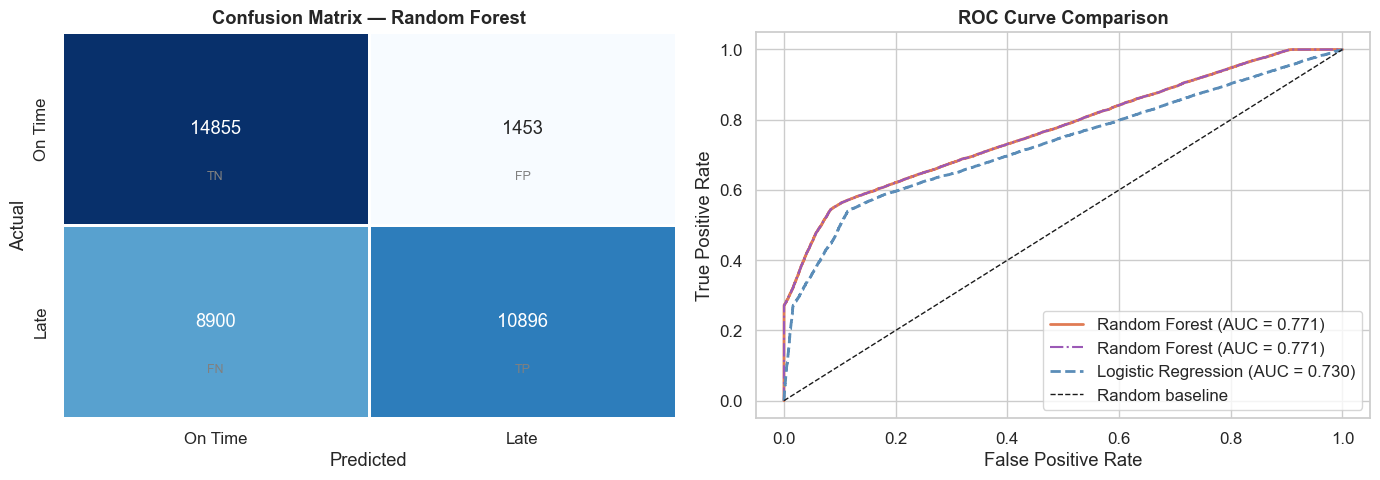

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Confusion Matrix ─────────────────────────────────────────────────────
# Rows = Actual class, Columns = Predicted class
# Top-left (TN): correctly predicted On Time
# Top-right (FP): predicted Late but was actually On Time (false alarm)
# Bottom-left (FN): predicted On Time but was actually Late (missed delay)
# Bottom-right (TP): correctly predicted Late
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['On Time', 'Late'],
            yticklabels=['On Time', 'Late'],
            linewidths=1, cbar=False)
axes[0].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
axes[0].set_ylabel('Actual')     # rows represent what actually happened
axes[0].set_xlabel('Predicted')  # columns represent what the model predicted

# Add TP/TN/FP/FN labels inside each cell for clarity
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        axes[0].text(j + 0.5, i + 0.75, labels[i][j],
                     ha='center', va='center', fontsize=9, color='gray')

# ── ROC Curve ────────────────────────────────────────────────────────────
# ROC = Receiver Operating Characteristic
# x-axis: False Positive Rate (FPR) — fraction of on-time orders wrongly predicted late
# y-axis: True Positive Rate (TPR) — fraction of late orders correctly caught
# A perfect model goes straight to top-left; the diagonal = random guessing
fpr_best, tpr_best, _ = roc_curve(y_test, best_probs)
fpr_rf,   tpr_rf,   _ = roc_curve(y_test, rf_probs)
fpr_lr,   tpr_lr,   _ = roc_curve(y_test, lr.predict_proba(X_test_scaled)[:, 1])

# Plot all three models on the same ROC chart for comparison
axes[1].plot(fpr_best, tpr_best, color='#E07B54', linewidth=2,
             label=f'{best_name} (AUC = {roc_auc_score(y_test, best_probs):.3f})')
axes[1].plot(fpr_rf,   tpr_rf,   color='#9B59B6', linewidth=1.5, linestyle='-.',
             label=f'Random Forest (AUC = {rf_auc:.3f})')
axes[1].plot(fpr_lr,   tpr_lr,   color='#5B8DB8', linewidth=2, linestyle='--',
             label=f'Logistic Regression (AUC = {lr_auc:.3f})')
# The diagonal dashed line represents random guessing (AUC = 0.5)
axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison', fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### 4.4 Feature Importance

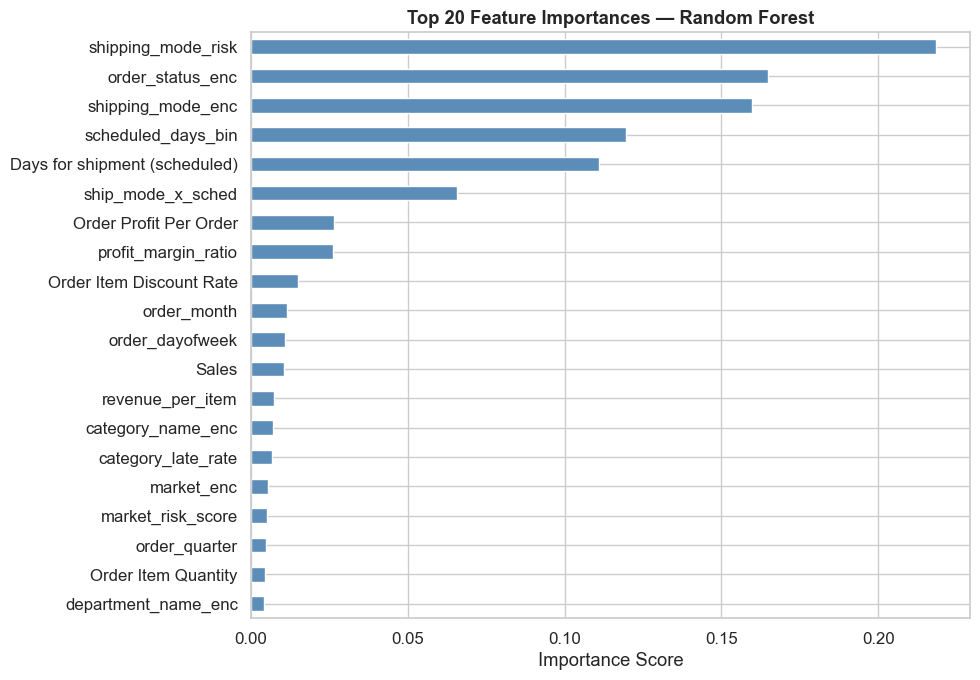

In [23]:
# Tree-based models (Random Forest, Gradient Boosting) provide feature_importances_
# This measures how much each feature reduces impurity across all trees
# Higher score = the feature contributes more to making correct predictions
importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLS)

# Sort ascending and take the top 20 most important features
top_features = importances.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
# Horizontal bar chart — longest bar = most important feature
top_features.plot(kind='barh', ax=ax, color='#5B8DB8', edgecolor='white')
ax.set_title(f'Top 20 Feature Importances — {best_name}', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

### 4.5 Predicted Probability Distribution

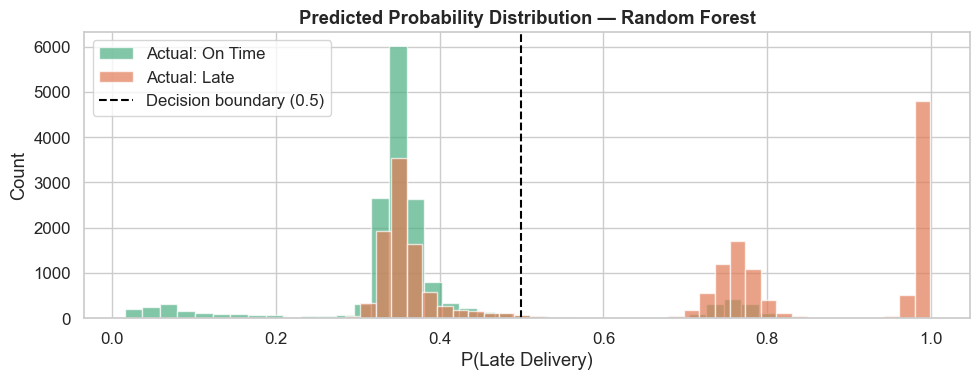

In [24]:
fig, ax = plt.subplots(figsize=(10, 4))

# Separate the probabilities by their actual label
# probs_on_time: predicted probabilities for orders that were actually on time (y_test == 0)
# probs_late:    predicted probabilities for orders that were actually late (y_test == 1)
probs_on_time = best_probs[y_test == 0]
probs_late    = best_probs[y_test == 1]

# Overlaid histograms — a good model shows clear separation between the two distributions
# If both histograms overlap heavily, the model is struggling to distinguish classes
ax.hist(probs_on_time, bins=40, alpha=0.7, color='#4CAF82', label='Actual: On Time')
ax.hist(probs_late,    bins=40, alpha=0.7, color='#E07B54', label='Actual: Late')

# Vertical dashed line at 0.5 — the default decision threshold
# Orders with probability > 0.5 are predicted Late; ≤ 0.5 are predicted On Time
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision boundary (0.5)')
ax.set_title(f'Predicted Probability Distribution — {best_name}', fontweight='bold')
ax.set_xlabel('P(Late Delivery)')   # x-axis = predicted probability of being late
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Save Model & Predictions

In [25]:
# Bundle the model together with its metadata into a dictionary
# Saving all components together makes it easy to reload and use the model later
model_data = {
    'model'       : best_model,    # the trained classifier object
    'model_name'  : best_name,     # string name for logging/display
    'feature_cols': FEATURE_COLS,  # the exact feature list used — important for inference
    'scaler'      : scaler         # StandardScaler fitted on train data (needed if using LR)
}

# pickle.dump serialises the Python object to bytes and writes it to the file
# 'wb' = write in binary mode (required for pickle)
with open('../models/delay_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print(f'✅ Best model ({best_name}) saved → models/delay_model.pkl')
print(f'   Test Accuracy : {best_acc:.4f}')
print(f'   Train Accuracy: {best_train_acc:.4f}')
print(f'   Train-Test Gap: {best_train_acc - best_acc:.4f}')

✅ Best model (Random Forest) saved → models/delay_model.pkl
   Test Accuracy : 0.7132
   Train Accuracy: 0.7229
   Train-Test Gap: 0.0096


In [26]:
# Generate predictions for ALL 180,519 orders — not just the test set
# The agent in Notebook 4 needs risk scores for every order, not just the 20% test split
all_probs = best_model.predict_proba(X)[:, 1]  # probability of being late for every row
all_preds = best_model.predict(X)              # predicted class (0 or 1) for every row

# Start with the processed data (Order Id + features + actual target)
predictions_df = df[(['Order Id'] if 'Order Id' in df.columns else []) + FEATURE_COLS + [TARGET_COL]].copy()

# Add three new columns to the DataFrame:
predictions_df['predicted_late']     = all_preds                        # model's class prediction
predictions_df['delay_probability']  = all_probs.round(4)               # model's confidence (0–1)
predictions_df['prediction_correct'] = (all_preds == df[TARGET_COL]).astype(int)  # 1=correct, 0=wrong

# Save to CSV for Notebook 4 to consume
predictions_df.to_csv('../Datasets/predictions.csv', index=False)

print(f'✅ Predictions saved → Datasets/predictions.csv')
print(f'   Shape: {predictions_df.shape[0]:,} rows × {predictions_df.shape[1]} cols')
print(f'   Overall model accuracy on full data: {(all_preds == df[TARGET_COL]).mean()*100:.2f}%')
print('\n→ Next step: Run Notebook 4 — Risk Scoring + Agent Logic')

✅ Predictions saved → Datasets/predictions.csv
   Shape: 180,519 rows × 31 cols
   Overall model accuracy on full data: 72.09%

→ Next step: Run Notebook 4 — Risk Scoring + Agent Logic
